# 1. Answer the questions from the introduction

### 1.a. What is leave-one-out ? Provide limitations and strenghs.
leave-one-out или cross-validation - это метод разбиения данных на части, чтобы обучать и проверять модель.

Сначала мы делим данные на тренировочную и тестовую части, как правило на тестовую отсвляют 0,2 части от всего датасета. Но только тренировочной части мало, так как надо подобрать бы гиперпараметры, а ещй бы признаки отобрать, а проверять и подбирать это на тестовой выборке нельзя, так как будет утечка данных и модель подстроится под определённые тестовые данные. Поэтому нужно от тренирвоочной части отделиь валидационную, на которой и будет происходить подбор гиперпарамтеров и остльаного.

Но просто отделить 0,1 часть от тренировочной выборки бывает мало, для получения объективных результатов и опять таки не перербучиться на определённой выборке. 

Поэтому используют метод cross-validation, который делить тренировочкую выборку на k фолдов, то есть частей, и принимет один из фолдов за валидационную, а на остальных k-1 фолдах обучается. И так происходит k раз, на каждом шаге меняя валидационный фолд. 

Для анализа берут среднее значение метрик. Это позволяет не переобучать модель и использовать больше данных, как тренировочные.

Ограничениями метода:
* если данных очень мало, то при делении на части, валидационная часть будет очень мала, из-за чего значения метрик могут быть не стабильны. 
* также важным является способ разбиения на флоды, так как при рандомном разбиении или наоборот при разбиении по порядку данные могут неарвмерно поделаиться, и не в валидационной выборке не будет каких то классов
* стоит также отметить вычислительные затраты, так как если данных очень много и одна модель долго обучается, то при CV надо будет обучить k раз нашу модель

Сильные стороны:
* основной слиьной стороной данного метода является то, что он помогает бороться с переобучением, и не подстраиваться под определённую выборку, и получать метрики в целом по датасету. То есть получать более общие оценки
* также он помогает задействовать все данные, что может быть очень важно, если данных не так много, как хотелось бы

### 1.b. How do Grid Search, Randomized Grid Search, and Bayesian optimization work ?

Grid Search - мы подаем как правило словарь, в котором для каждой переменной указаны все варианиы её значений (варианты которые мы рассматриваем). Далее метод создаёт все возможные комбинации этих параметров и обучает модель на каждом наборе, сравнивает по заданной метрике в возвращает те парметры, при которых модель показала наилучшие результаты по заданной метрике. Метод очень ресурсоёмкий, и не даёт точных гарантий, что мы попадём в экстремум.

Randomized Grid Searc - также перебирает комбинации параметров, однако не из заданного значения, а с заданной вероятностью выбора того или иного значения. Плюс этого метода в том, что есть большой шанс попать в точку максимума, или по крайне мере рядом с ней, что позволит "нащупать" место, в котором стоит искать значения параемтров. Опять таки работатет быстрее обычного метода, и вносит элемент случайности в подбор значений, что может быть эффективнее прямого перебора.

Bayesian Optimization - это стратегия последовтельного поиска максимума функции f(x), где x - это гиперпараметры, f - метрика. Главное отличие от обычного перебора в том, что BO строит аппроксимацию функции f вместе с оценкой неопределённости, и использует эту апроксимацию, чтобы выбрать следующие точки, где проверить работу модели. То есть получается не перебор, а последовательно модель пытается нащупать то место, где будте лучший результат, при это балансируя между двуми понятиями. exploration - исследование, то есть смотреть те места, где дисперсия высока и есть шанс найти новый хороший резултат. 
А также exploitation - эксплуатаця, то есть исследовать те точки, где среднее нашей модели велико, а занчит тут должны быть стабильно более высокие результаты. При таком подходе, сходимость наступает быстрее, и получакется найти максимум, или приближенный максимум гораздо быстроее прямого перебора.

### 1.c. Explain classification of feature selection methods. Explain how Pearson and Chi2 work. Explain how Lasso works. Explain what permutation significance is. Become familiar with SHAP.

Классификация методов выбора призанков.

Без обучения:
* убрать те признаки, в которых не для всех примеров есть данные, то есть те, в которых много Nan занчений;
* убрать признаки с высокой мультиколлениарностью, то есть оставить один их этих признаков. Это логично, так как для модели эти признаки делают одно и то же, но при этом могут плохо сказаться на сходимости или интпретации резульатов модели;
* убрать признаки, дисперсия которых близка у нулю. Это значит, что признак для разных объектов выборки не меняет значение существенно, или вообще не меняет. А в таком случае данный признак бесполезный для модели, если он одинаковый для всех примеров.

С обученим или supervised:
1. Filtres - методы, в которых отбор признаков происходит за счёт фильтрации. То есть высчитаывается какое-то отношение между признаком и целевой переменной, и потом выбриают топ-k признакво по этой метрике.
    * Pearson - вычисляется коэффициент корреляции Пирсона между признаком и таргетом 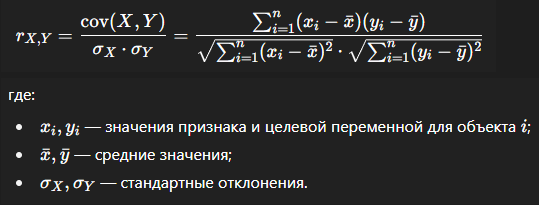. И потом просходит выбор, напирмер по |r|> какого значения, то есть чтобы корреляция была.
    * Chi2 - хи-квадрат тест проверяет гипотезу независимости двух категориальных переменных. 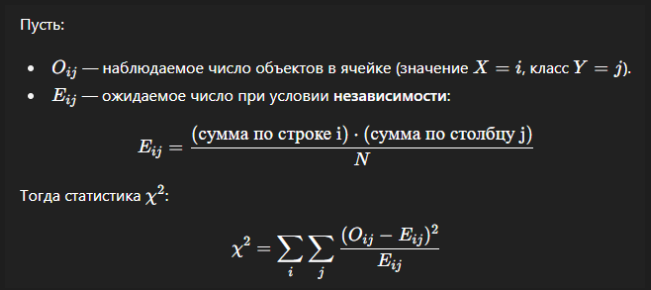, если хи-квадрат велико, значит зависимость между признаком и таргетом есть, тогда стоит выбрать это принзнак.

2. Embedded - встроеные, то есть это такой метод отбора параметров, который призводит подбор во время обучени модели.
    * Lasso - регуляризация, где добавляется модуль весов признаков умноженный на коэффициент. 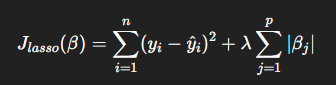. По смыслу, если нам надо уменьшить значения целевой функции, но при этом есть слагаемое, которое умножается на все веса признаков и прибавляется, то лучшим решением будет обнулить некторые веса. И обнулить стоит те веса, которые  соотвусвтуют признакам, которые меньше всего воздействуют на решение модели. То есть во время обучения веса некторых признаков могут обнулиться, или быть очень малыми, так как для предсказания она мало нужны. Либо графическое объяснение в том, что данная регуляризация на графике обрузет ромб, а решение нашей имеет вид эллипса. А мы пытваемя найти их пересечение, тогда велика верятность, что пресечению будет в одном из углов ромба. А в угле значение веса какого-то признака будет нулевое. В пространсвенном случае будет просто гипер ромб, а углу которого не однин вес нулевой, а несколько уже.

3. Permutation significance - близкий к wrapped(обертывающим) методам, в которых отбор проихсодит после обучения модели, и вообще мы отбриаем признаки, смотря на значения метрики, после обучения модели. Идея же метода в том, что мы берём какой-то признак, рандомно перемешиваем его значения, то есть нарушаем свзять этого признака с целевой переменной и заново обучаем модель. Смотри на метрику, если она не поменялась - значит свзязь признака и таргета мнимая, и можно этот признак убрать. Если же метрика сильно упала, значит таргет зависит от значений этого признака и он важен в нашей модели.

# 2. Introduction - do all the preprocessing from the previous lesson

In [1]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import KFold, StratifiedKFold, GroupKFold, TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error
import shap
from scipy.stats import loguniform, uniform
import optuna

### 2.a. Read all the data

In [2]:
df = pd.read_json('data/train.json')
df.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


### 2.b. Preproccesing the 'Interest Level' feature

In [3]:
dict_interest_level = {
    'low' : 0,
    'medium' : 1,
    'high' : 2
}
df.interest_level = [dict_interest_level[x] for x in  df.interest_level]

### 2.c. Create features

In [4]:
def del_symbols(list_of_features):
    for i in range(len(list_of_features)):
        list_of_features[i] = list_of_features[i].replace('[', '').replace(']', '').replace('\'', '').replace('\"', '').replace(' ', '').lower()
    return list_of_features

In [5]:
df.features = df.features.apply(del_symbols)

In [6]:
all_features = []
for index, row in df.iterrows():
    for feature in row['features']:
        all_features.append(feature)

In [7]:
c = Counter(all_features)
c.most_common(20)

[('elevator', 26273),
 ('hardwoodfloors', 23559),
 ('catsallowed', 23540),
 ('dogsallowed', 22035),
 ('doorman', 20967),
 ('dishwasher', 20808),
 ('laundryinbuilding', 18944),
 ('nofee', 18079),
 ('fitnesscenter', 13257),
 ('laundryinunit', 9435),
 ('pre-war', 9149),
 ('roofdeck', 6613),
 ('outdoorspace', 5270),
 ('diningroom', 5150),
 ('highspeedinternet', 4299),
 ('balcony', 3058),
 ('swimmingpool', 2730),
 ('newconstruction', 2608),
 ('terrace', 2313),
 ('exclusive', 2167)]

In [8]:
names_of_new_features = [x[0] for x in c.most_common(20)]

In [9]:
for new_feature in names_of_new_features:
    is_in_feature = []
    counter = 0
    for features in df.features:
        counter +=1
        if new_feature in features:
            is_in_feature.append(1)
        else: 
            is_in_feature.append(0)
    df[new_feature] = is_in_feature

In [10]:
feature_list = ['bathrooms', 'bedrooms', 'interest_level']
for feature in names_of_new_features:
    feature_list.append(feature)
feature_list

['bathrooms',
 'bedrooms',
 'interest_level',
 'elevator',
 'hardwoodfloors',
 'catsallowed',
 'dogsallowed',
 'doorman',
 'dishwasher',
 'laundryinbuilding',
 'nofee',
 'fitnesscenter',
 'laundryinunit',
 'pre-war',
 'roofdeck',
 'outdoorspace',
 'diningroom',
 'highspeedinternet',
 'balcony',
 'swimmingpool',
 'newconstruction',
 'terrace',
 'exclusive']

In [11]:
df = df[(df['price'] > df['price'].quantile(0.01)) & (df['price'] < df['price'].quantile(0.99))]

In [12]:
X = df[feature_list]
y = df['price']

# 3. Implement the next methods

### 3.a. Split data into 2 parts randomly with parametr test_size (ration from 0 to 1), return training and test samples.

In [13]:
def split_2_parts_random(X, y, test_size=0.2, random_seed=21):
    np.random.seed(random_seed)

    if len(X) != len(y):
        return 'X и y должны быть одинаковой длины'
    
    indexces = np.arange(len(X))
    np.random.shuffle(indexces)
    split_index = int(len(X) * (1 - test_size))

    train_indexes = indexces[:split_index]
    test_indexes = indexces[split_index:]

    X_train, y_train = X.iloc[train_indexes], y.iloc[train_indexes]
    X_test, y_test = X.iloc[test_indexes], y.iloc[test_indexes]

    return X_train, X_test, y_train, y_test

In [14]:
X1_train, X1_test, y1_train, y1_test = split_2_parts_random(X,y)
X2_train, X2_test, y2_train, y2_test = split_2_parts_random(X,y)

print(np.array_equal(X1_train, X2_train))
print(np.array_equal(X1_test, X2_test))

True
True


### 3.b. Randomly split data into 3 parts with parameters validation_size and test_size

In [15]:
def split_3_parts_randomly(X, y, test_size=0.2, validation_size=0.1, random_seed=21):
    np.random.seed(random_seed)

    if len(X) != len(y):
        return 'X and y должны быть одинаковой длины'
    
    indexces = np.arange(len(X))
    np.random.shuffle(indexces)

    split_train = int(len(X) * (1 - test_size - validation_size))
    split_validation = int(len(X) * (1 - test_size))

    train_indexes = indexces[:split_train]
    validation_indexces = indexces[split_train:split_validation]
    test_indexces = indexces[split_validation:]

    if (len(train_indexes) + len(validation_indexces) + len(test_indexces)) != len(X):
        return 'Ошибка в разбиении данных'

    X_train, X_validate, X_test = X.iloc[train_indexes], X.iloc[validation_indexces], X.iloc[test_indexces]
    y_train, y_validate, y_test = y.iloc[train_indexes], y.iloc[validation_indexces], y.iloc[test_indexces]

    return X_train, X_validate, X_test, y_train, y_validate, y_test

In [16]:
X_train, X_validate, X_test, y_train, y_validate, y_test = split_3_parts_randomly(X,y)

print(len(X_train))
print(len(X_validate))
print(len(X_test))

33840
4834
9669


### 3.c. Split data into 2 parts with parameter date_split

In [17]:
def split_2_parts_by_date(data, date_split, name_date_column):
    data_train = data[data[name_date_column] < date_split]
    data_test = data[data[name_date_column] >= date_split]

    return data_train, data_test

In [18]:
import pandas as pd

data = {
    'date': ['2024-01-15', '2024-01-03', '2024-01-20', '2024-01-08',
             '2024-01-25', '2024-01-01', '2024-01-12', '2024-01-28',
             '2024-01-05', '2024-01-18', '2024-01-09', '2024-01-22',
             '2024-01-07', '2024-01-14', '2024-01-30', '2024-01-02',
             '2024-01-11', '2024-01-26', '2024-01-16', '2024-01-04'],
    'feature': [10, 25, 8, 15, 12, 30, 18, 5, 22, 9, 17, 11, 20, 14, 3, 28, 16, 7, 13, 24],
    'target': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    'group': ['A', 'B', 'A', 'C', 'D', 'A', 'B', 'C', 'D', 'A', 
              'B', 'C', 'D', 'A', 'B', 'C', 'D', 'A', 'B', 'C'],
    'stratify_col': ['class_1', 'class_2', 'class_1', 'class_3', 'class_2', 
                     'class_1', 'class_2', 'class_3', 'class_2', 'class_1',
                     'class_2', 'class_3', 'class_2', 'class_1', 'class_2',
                     'class_3', 'class_2', 'class_3', 'class_3', 'class_3']
}

df_2 = pd.DataFrame(data)
df_2['date'] = pd.to_datetime(df_2['date'])
print(df_2)

         date  feature  target group stratify_col
0  2024-01-15       10       1     A      class_1
1  2024-01-03       25       0     B      class_2
2  2024-01-20        8       1     A      class_1
3  2024-01-08       15       0     C      class_3
4  2024-01-25       12       1     D      class_2
5  2024-01-01       30       0     A      class_1
6  2024-01-12       18       1     B      class_2
7  2024-01-28        5       0     C      class_3
8  2024-01-05       22       1     D      class_2
9  2024-01-18        9       0     A      class_1
10 2024-01-09       17       1     B      class_2
11 2024-01-22       11       0     C      class_3
12 2024-01-07       20       1     D      class_2
13 2024-01-14       14       0     A      class_1
14 2024-01-30        3       1     B      class_2
15 2024-01-02       28       0     C      class_3
16 2024-01-11       16       1     D      class_2
17 2024-01-26        7       0     A      class_3
18 2024-01-16       13       1     B      class_3


In [19]:
df_train, df_test = split_2_parts_by_date(df_2, '2024-01-20', 'date')
print(df_train)
print(df_test)

         date  feature  target group stratify_col
0  2024-01-15       10       1     A      class_1
1  2024-01-03       25       0     B      class_2
3  2024-01-08       15       0     C      class_3
5  2024-01-01       30       0     A      class_1
6  2024-01-12       18       1     B      class_2
8  2024-01-05       22       1     D      class_2
9  2024-01-18        9       0     A      class_1
10 2024-01-09       17       1     B      class_2
12 2024-01-07       20       1     D      class_2
13 2024-01-14       14       0     A      class_1
15 2024-01-02       28       0     C      class_3
16 2024-01-11       16       1     D      class_2
18 2024-01-16       13       1     B      class_3
19 2024-01-04       24       0     C      class_3
         date  feature  target group stratify_col
2  2024-01-20        8       1     A      class_1
4  2024-01-25       12       1     D      class_2
7  2024-01-28        5       0     C      class_3
11 2024-01-22       11       0     C      class_3


### 3.d. Split data into 3 parts with parameters validation_date and test_date

In [20]:
def split_3_parts_by_date(data, validation_date, test_date, name_date_column):
    train = data[data[name_date_column] < validation_date]
    validation = data[(data[name_date_column] >= validation_date) & (data[name_date_column] < test_date)]
    test = data[data[name_date_column] >= test_date]

    return train, validation, test

In [21]:
df_train, df_validation, df_test = split_3_parts_by_date(df_2,'2024-01-15', '2024-01-20', 'date')
print(df_train)
print(df_validation)
print(df_test)

         date  feature  target group stratify_col
1  2024-01-03       25       0     B      class_2
3  2024-01-08       15       0     C      class_3
5  2024-01-01       30       0     A      class_1
6  2024-01-12       18       1     B      class_2
8  2024-01-05       22       1     D      class_2
10 2024-01-09       17       1     B      class_2
12 2024-01-07       20       1     D      class_2
13 2024-01-14       14       0     A      class_1
15 2024-01-02       28       0     C      class_3
16 2024-01-11       16       1     D      class_2
19 2024-01-04       24       0     C      class_3
         date  feature  target group stratify_col
0  2024-01-15       10       1     A      class_1
9  2024-01-18        9       0     A      class_1
18 2024-01-16       13       1     B      class_3
         date  feature  target group stratify_col
2  2024-01-20        8       1     A      class_1
4  2024-01-25       12       1     D      class_2
7  2024-01-28        5       0     C      class_3


### 3.e. Make split procedure determrnistic. What does it mean?

Сделать разбиение детерменирвоанным - значит чтобы при каждом запуске с заданным random_seed, разбиение происзодило одинаковым образом, чтобы можно было перезапускать разбиаение и получать те же результаты.

Для разбиения по дате не надо ничего задавать, оно всегда будет одинаково разделять по дате.

А при ранздомном разбиении в функциях есть параметр random_seed, который в нутри функции задаёт его, из-за чего shuffle всегда одинаково перемешивает данные.

# 4. Implement the next cros-validation methods

### 4.a. K-Fold, where k is the input parametr, return a list of train and test indeces.

In [22]:
def my_KFold(X, k, shuffle = False, random_seed = 21):
    lenght = len(X)
    indices = np.arange(lenght)
    if shuffle:
        np.random.seed(random_seed)
        np.random.shuffle(indices)

    fold_sizes = np.full(k, lenght // k, dtype=int)
    fold_sizes[:lenght % k] += 1

    current = 0
    answer  = []

    for fold_size in fold_sizes:
        start, stop = current, current + fold_size
        test = indices[start:stop]
        train = np.concatenate([indices[:start], indices[stop:]])
        answer.append([train, test])
        current = stop
    
    return answer


In [23]:
for i,j in my_KFold(df_2, k=6, shuffle=True):
    print(i, '  |  ', j)

[ 5 17 18 11  6 14  1  2 12  3  8  0 16  4 15  9]   |   [ 7 10 19 13]
[ 7 10 19 13  6 14  1  2 12  3  8  0 16  4 15  9]   |   [ 5 17 18 11]
[ 7 10 19 13  5 17 18 11  2 12  3  8  0 16  4 15  9]   |   [ 6 14  1]
[ 7 10 19 13  5 17 18 11  6 14  1  8  0 16  4 15  9]   |   [ 2 12  3]
[ 7 10 19 13  5 17 18 11  6 14  1  2 12  3  4 15  9]   |   [ 8  0 16]
[ 7 10 19 13  5 17 18 11  6 14  1  2 12  3  8  0 16]   |   [ 4 15  9]


### 4.b. Grouped K-Fold, where k and group_filed are input parameters

In [24]:
def my_group_KFold(X, k, group_field):
    answer = []

    groups_name = X[group_field].unique()

    if len(groups_name) < k:
        print('Количество групп меньше числа фолдов')
        return
    
    group_indices = {
        groups_name[i] : np.where(X[group_field].values == groups_name[i])[0] for i in range(0, len(groups_name))
    }
    
    fold_sizes_by_group = np.full(k, len(groups_name) // k)
    fold_sizes_by_group[:len(groups_name) % k] += 1

    mark_of_group = 0

    for i in range(k):
        start = mark_of_group
        end = mark_of_group + fold_sizes_by_group[i]

        test_groups = groups_name[start:end]
        train_groups = [groups_name[j] for j in range(len(groups_name)) if groups_name[j] not in test_groups]
        
        test_indices = []
        train_indices = []

        for group in test_groups:
            test_indices = np.concatenate([test_indices, group_indices[group]])

        for group in train_groups:
            train_indices = np.concatenate([train_indices, group_indices[group]])

        answer.append([train_indices.astype(int), test_indices.astype(int)])
        
        mark_of_group = end
        
    return answer    

In [25]:
for train, test in my_group_KFold(df_2, 3, group_field='group'):
    print(train, '  |  ', test)

[ 3  7 11 15 19  4  8 12 16]   |   [ 0  2  5  9 13 17  1  6 10 14 18]
[ 0  2  5  9 13 17  1  6 10 14 18  4  8 12 16]   |   [ 3  7 11 15 19]
[ 0  2  5  9 13 17  1  6 10 14 18  3  7 11 15 19]   |   [ 4  8 12 16]


### 4.c. Stratified K-Fold, where k and stratify_filed are input parameters

In [26]:
def my_StratifiedKFold(X, k, stratify_field, shuffle= False, random_seed = 21):
    answer = np.empty((k,2), dtype=object)
    for i in range(k):
        for j in range(2):
            answer[i,j] = np.array([], dtype=int)

    class_names = X[stratify_field].unique()

    class_indices = {
        class_names[i] : np.where(X[stratify_field].values == class_names[i])[0] for i in range(0, len(class_names))
    }

    if shuffle:
        np.random.seed(random_seed)
        for i in range(len(class_names)):
            np.random.shuffle(class_indices[class_names[i]])

    is_first = 1


    for clas in class_names:
        if len(class_indices[clas]) < k:
            raise print('Размер уникального класса меньше количсетва фолдов, стратифицированное разбиение невозможно')

        indices = class_indices[clas]
        fold_size = np.full(k, len(class_indices[clas]) // k)
        fold_size[:len(class_indices[clas]) % k] += 1
        current = 0

        sub_answer  = []

        for j in range(k):
            start = current
            end = current + fold_size[j]

            sub_test = indices[start:end]
            sub_train = np.concatenate([indices[:start], indices[end:]])
            
            sub_answer.append([sub_train, sub_test])

            current = end
    
        for i in range(k):
            for j in range(2):
                if is_first == 1:
                    answer[i][j] = sub_answer[i][j]
                else:
                    answer[i][j] = np.append(answer[i][j], sub_answer[i][j])
        is_first = 0
        
    return answer

In [27]:
answer = my_StratifiedKFold(df_2, 3, 'stratify_col', shuffle=False)
for i,j in answer:
    print(i, '  |  ', j)

[ 5  9 13  8 10 12 14 16 15 17 18 19]   |   [ 0  2  1  4  6  3  7 11]
[ 0  2 13  1  4  6 14 16  3  7 11 18 19]   |   [ 5  9  8 10 12 15 17]
[ 0  2  5  9  1  4  6  8 10 12  3  7 11 15 17]   |   [13 14 16 18 19]


### 4.d. Time series split, where k and date_field are input parametesrs

In [28]:
def my_time_series_split(X, k, date_field):
    k += 1
    X_copy = X.sort_values(by=date_field)
    label_sorted = X_copy.index.values
    indices = X.index.get_indexer(label_sorted)

    fold_size = np.full(k, len(indices) // k)
    fold_size[:len(indices) % k] += 1

    currnet = 0
    answer = []

    for i in range(k-1):
        start = currnet + fold_size[i]
        end = start + fold_size[i+1]

        test_indices = indices[start:end]
        train_indices = indices[:start]

        answer.append([train_indices, test_indices])

        currnet = start
    
    return answer
    

In [29]:
for i,j in my_time_series_split(df_2, 5, 'date'):
    print(i, '  |  ', j)

[ 5 15  1 19]   |   [ 8 12  3 10]
[ 5 15  1 19  8 12  3 10]   |   [16  6 13]
[ 5 15  1 19  8 12  3 10 16  6 13]   |   [ 0 18  9]
[ 5 15  1 19  8 12  3 10 16  6 13  0 18  9]   |   [ 2 11  4]
[ 5 15  1 19  8 12  3 10 16  6 13  0 18  9  2 11  4]   |   [17  7 14]


# 5. Cross-validation comparison

### 5.a. Apply all the validation methods implemented above to our dataset. To apply Stratfied algotithm you should preprocess target.

Предобработка данных, изменили тип столбца created на временной. Таргетную переменную формализовали в категорильную, чтобы применить стратификацию.

In [30]:
df['created'] = pd.to_datetime(df['created'])
df['price_bins'] =  pd.qcut(df['price'], 4, labels=[0,1,2,3])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48343 entries, 4 to 124009
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   bathrooms          48343 non-null  float64       
 1   bedrooms           48343 non-null  int64         
 2   building_id        48343 non-null  object        
 3   created            48343 non-null  datetime64[ns]
 4   description        48343 non-null  object        
 5   display_address    48343 non-null  object        
 6   features           48343 non-null  object        
 7   latitude           48343 non-null  float64       
 8   listing_id         48343 non-null  int64         
 9   longitude          48343 non-null  float64       
 10  manager_id         48343 non-null  object        
 11  photos             48343 non-null  object        
 12  price              48343 non-null  int64         
 13  street_address     48343 non-null  object        
 14  interest_l

### Далее применение написанных методов и аналогичных методов из sklearn будут прописаны вместе, для комфортного сравнения и записи результатов.

#### 1.Обычный KFold

In [31]:
my_splits_KFold = my_KFold(df, 5)
kf = KFold(n_splits=5)
kf.get_n_splits(df)
for i, (train, test) in enumerate(kf.split(df)):
    print(f"Fold {i:<3}")
    print(f'Train: index=    {str(train):<44}  |   Test: index=    {str(test):<44}')
    print(f'my_Train: index= {str(my_splits_KFold[i][0]):<40}     |   my_Test: index= {str(my_splits_KFold[i][1]):<40}')

Fold 0  
Train: index=    [ 9669  9670  9671 ... 48340 48341 48342]     |   Test: index=    [   0    1    2 ... 9666 9667 9668]         
my_Train: index= [ 9669  9670  9671 ... 48340 48341 48342]     |   my_Test: index= [   0    1    2 ... 9666 9667 9668]     
Fold 1  
Train: index=    [    0     1     2 ... 48340 48341 48342]     |   Test: index=    [ 9669  9670  9671 ... 19335 19336 19337]   
my_Train: index= [    0     1     2 ... 48340 48341 48342]     |   my_Test: index= [ 9669  9670  9671 ... 19335 19336 19337]
Fold 2  
Train: index=    [    0     1     2 ... 48340 48341 48342]     |   Test: index=    [19338 19339 19340 ... 29004 29005 29006]   
my_Train: index= [    0     1     2 ... 48340 48341 48342]     |   my_Test: index= [19338 19339 19340 ... 29004 29005 29006]
Fold 3  
Train: index=    [    0     1     2 ... 48340 48341 48342]     |   Test: index=    [29007 29008 29009 ... 38672 38673 38674]   
my_Train: index= [    0     1     2 ... 48340 48341 48342]     |   my_Test: in

Если параметр shuffle=False, то резульаты разбиения полностью совпадают с реализацией sklearn. Сравнивать распределение признаков не имеет смысла, так как при обычном KFold не учитываются никакие распределения никаких признаков, поэтому и тут сверять нечего не надо.

#### 2. Grouped K-Fold

In [32]:
my_splits_GroupedKFold = my_group_KFold(df, 3, 'interest_level')
for train,test in my_splits_GroupedKFold:
    print(len(train), '  |  ', len(test))
    print(len(train) + len(test),'\n')

37229   |   11114
48343 

14671   |   33672
48343 

44786   |   3557
48343 



In [33]:
groups = df.interest_level
group_kfold = GroupKFold(n_splits=3)

for i, (train, test) in enumerate(group_kfold.split(df, groups=groups)):
    print(f'Fold {i}')
    print(len(train), '  |  ', len(test))
    print(len(train) + len(test))


Fold 0
14671   |   33672
48343
Fold 1
37229   |   11114
48343
Fold 2
44786   |   3557
48343


По разделения по индексам у меня логика отличная от той, что прописана в sklearn, поэтому сравнить напрямую индексы не получится, однако по по размерам train и test можно увидеть, что корректно делит на группы, группа присутсвует целиком либо в train, либо в test. Распределения значения признаков значит тоже будут примерно одинаковыми, отличия могут возникать только при большом количестве уникальных групп, тогда правила разбиения могут по разному срабоать, но главный смысл алгоритма рабоатет корректно.

#### 3. StratifiedKFold

In [34]:
def have_percentage_price_bins(indices):
    answer = []
    for i in range(4):
        answer.append((df.iloc[indices]['price_bins'] == i).sum() / len(indices))
    return answer

In [35]:
my_splits_StratifiedKFold = my_StratifiedKFold(df, 5, 'price_bins')
my_splits_StratifiedKFold

array([[array([ 9897,  9901,  9902, ..., 48334, 48341, 48342], shape=(38673,)),
        array([   0,    7,    8, ..., 9634, 9636, 9638], shape=(9670,))],
       [array([    0,     7,     8, ..., 48334, 48341, 48342], shape=(38673,)),
        array([ 9897,  9901,  9902, ..., 19300, 19302, 19303], shape=(9670,))],
       [array([    0,     7,     8, ..., 48334, 48341, 48342], shape=(38674,)),
        array([19626, 19631, 19640, ..., 28653, 28655, 28658], shape=(9669,))],
       [array([    0,     7,     8, ..., 48334, 48341, 48342], shape=(38676,)),
        array([29341, 29342, 29346, ..., 38327, 38328, 38329], shape=(9667,))],
       [array([    0,     7,     8, ..., 38327, 38328, 38329], shape=(38676,)),
        array([38876, 38877, 38879, ..., 48334, 48341, 48342], shape=(9667,))]],
      dtype=object)

In [36]:
have_percentage_price_bins(my_splits_StratifiedKFold[0][0])

[np.float64(0.26742171540868304),
 np.float64(0.23587515837923098),
 np.float64(0.24670959067049364),
 np.float64(0.24999353554159232)]

In [37]:
i = 1
for train, test in my_splits_StratifiedKFold:
    print(f'Fold {i}')
    print('Train:')
    print(f'Percentage: {have_percentage_price_bins(train)}')
    print(f'Mean: {df.iloc[train].price.mean()}')
    print(f'Median: {df.iloc[train].price.median()}\n')

    print('test:')
    print(f'Percentage: {have_percentage_price_bins(test)}')
    print(f'Mean: {df.iloc[test].price.mean()}')
    print(f'Median: {df.iloc[test].price.median()}\n-----------------------------\n')

    i += 1


Fold 1
Train:
Percentage: [np.float64(0.26742171540868304), np.float64(0.23587515837923098), np.float64(0.24670959067049364), np.float64(0.24999353554159232)]
Mean: 3535.3849197114264
Median: 3150.0

test:
Percentage: [np.float64(0.2674250258531541), np.float64(0.2358841778697001), np.float64(0.2467425025853154), np.float64(0.24994829369183041)]
Mean: 3534.2965873836606
Median: 3150.0
-----------------------------

Fold 2
Train:
Percentage: [np.float64(0.26742171540868304), np.float64(0.23587515837923098), np.float64(0.24670959067049364), np.float64(0.24999353554159232)]
Mean: 3531.1829958886046
Median: 3150.0

test:
Percentage: [np.float64(0.2674250258531541), np.float64(0.2358841778697001), np.float64(0.2467425025853154), np.float64(0.24994829369183041)]
Mean: 3551.101240951396
Median: 3150.0
-----------------------------

Fold 3
Train:
Percentage: [np.float64(0.26741480064125767), np.float64(0.23586905931633656), np.float64(0.24672906862491598), np.float64(0.2499870714174898)]
Mean:

In [ ]:
skf = StratifiedKFold(n_splits=5)

for i, (train, test) in enumerate(skf.split(df, df['price_bins'])):
    print(f'Fold {i}')
    print('Train:')
    print(f'Percentage: {have_percentage_price_bins(train)}')
    print(f'Mean: {df.iloc[train].price.mean()}')
    print(f'Median: {df.iloc[train].price.median()}\n')

    print('test:')
    print(f'Percentage: {have_percentage_price_bins(test)}')
    print(f'Mean: {df.iloc[test].price.mean()}')
    print(f'Median: {df.iloc[test].price.median()}\n-----------------------------\n')

Fold 0
Train:
Percentage: [np.float64(0.26741480064125767), np.float64(0.23586905931633656), np.float64(0.24672906862491598), np.float64(0.2499870714174898)]
Mean: 3535.3761183223874
Median: 3150.0

test:
Percentage: [np.float64(0.2674526838349364), np.float64(0.23590857379253283), np.float64(0.24666459820043438), np.float64(0.2499741441720964)]
Mean: 3534.3316785603474
Median: 3150.0
-----------------------------

Fold 1
Train:
Percentage: [np.float64(0.26741480064125767), np.float64(0.23586905931633656), np.float64(0.24672906862491598), np.float64(0.2499870714174898)]
Mean: 3531.181026012308
Median: 3150.0

test:
Percentage: [np.float64(0.2674526838349364), np.float64(0.23590857379253283), np.float64(0.24666459820043438), np.float64(0.2499741441720964)]
Mean: 3551.1111800599856
Median: 3150.0
-----------------------------

Fold 2
Train:
Percentage: [np.float64(0.26741480064125767), np.float64(0.23586905931633656), np.float64(0.24672906862491598), np.float64(0.2499870714174898)]
Mean:

Опять таки напрямую порядок индексов сравнить не получится, а вот по процентному соотношению и значениями срденего и медианы сразу видно, что разделение правильное, причем видно, что в test и train сохраняется процентное наличие классов.

#### 4. Time series split

In [39]:
my_splits_time = my_time_series_split(df.sort_values(by='created'), 5, 'created')
my_splits_time

[[array([   0,    1,    2, ..., 8055, 8056, 8057], shape=(8058,)),
  array([ 8059,  8058,  8060, ..., 16112, 16113, 16114], shape=(8057,))],
 [array([    0,     1,     2, ..., 16112, 16113, 16114], shape=(16115,)),
  array([16115, 16116, 16117, ..., 24169, 24170, 24171], shape=(8057,))],
 [array([    0,     1,     2, ..., 24169, 24170, 24171], shape=(24172,)),
  array([24172, 24173, 24174, ..., 32226, 32227, 32228], shape=(8057,))],
 [array([    0,     1,     2, ..., 32226, 32227, 32228], shape=(32229,)),
  array([32229, 32230, 32231, ..., 40283, 40284, 40285], shape=(8057,))],
 [array([    0,     1,     2, ..., 40283, 40284, 40285], shape=(40286,)),
  array([40286, 40287, 40288, ..., 48340, 48341, 48342], shape=(8057,))]]

In [40]:
for train, test in my_splits_time:
    print(f'Train:  {train}')
    print(f'Test:  {test}')

Train:  [   0    1    2 ... 8055 8056 8057]
Test:  [ 8059  8058  8060 ... 16112 16113 16114]
Train:  [    0     1     2 ... 16112 16113 16114]
Test:  [16115 16116 16117 ... 24169 24170 24171]
Train:  [    0     1     2 ... 24169 24170 24171]
Test:  [24172 24173 24174 ... 32226 32227 32228]
Train:  [    0     1     2 ... 32226 32227 32228]
Test:  [32229 32230 32231 ... 40283 40284 40285]
Train:  [    0     1     2 ... 40283 40284 40285]
Test:  [40286 40287 40288 ... 48340 48341 48342]


In [41]:
tscv = TimeSeriesSplit(n_splits=5)

for i, (train, test) in enumerate(tscv.split(df.sort_values(by='created'))):
    print(f'Fold {i}')
    print(f'Train:  {train}')
    print(f'Test:  {test}')

Fold 0
Train:  [   0    1    2 ... 8055 8056 8057]
Test:  [ 8058  8059  8060 ... 16112 16113 16114]
Fold 1
Train:  [    0     1     2 ... 16112 16113 16114]
Test:  [16115 16116 16117 ... 24169 24170 24171]
Fold 2
Train:  [    0     1     2 ... 24169 24170 24171]
Test:  [24172 24173 24174 ... 32226 32227 32228]
Fold 3
Train:  [    0     1     2 ... 32226 32227 32228]
Test:  [32229 32230 32231 ... 40283 40284 40285]
Fold 4
Train:  [    0     1     2 ... 40283 40284 40285]
Test:  [40286 40287 40288 ... 48340 48341 48342]


Кароче мой метод даже лучше, так как он внутри сортирует значения по дате ещё, а sklearn думает, что данные уже отсортированы, поэтому на сортированных данных у меня значения сходятся.

### 5.d. Compare all validation schemes. Choose the best one.

In [42]:
for i in range(5):
    print(f'Fold {i}')

    print('Mean:')
    print(f'KFold: {df.iloc[my_splits_KFold[i][0]].price.mean()}')
    if i<3:
        print(f'GroupedKFold: {df.iloc[my_splits_GroupedKFold[i][0]].price.mean()}')
    print(f'StratifiedKFold: {df.iloc[my_splits_StratifiedKFold[i][0]].price.mean()}\n-------------------------\n')

Fold 0
Mean:
KFold: 3533.6276826808707
GroupedKFold: 3643.9568884471782
StratifiedKFold: 3535.3849197114264
-------------------------

Fold 1
Mean:
KFold: 3529.376894037338
GroupedKFold: 3074.754004498671
StratifiedKFold: 3531.1829958886046
-------------------------

Fold 2
Mean:
KFold: 3528.691343021151
GroupedKFold: 3595.5564462108696
StratifiedKFold: 3534.6690541449034
-------------------------

Fold 3
Mean:
KFold: 3540.31570782159
StratifiedKFold: 3539.4630778777537
-------------------------

Fold 4
Mean:
KFold: 3543.8241241111828
StratifiedKFold: 3535.135743096494
-------------------------



Если смотреть по средним и медианным значениям, то особой разницы между методами нет. Везде значения цены примерно одинаковые. 

Также в нашем задании нет ярко выраженных групп или классов, по которым бы стоило применять GroupKFold, а также значения price не имеют тяжелого хвоста, из-за чего стратифицировать данные не надо при разбиении. Стратификация больше нужна, когда у нас таргет категориальный.

Поэтому в данном задании подоёдет и обычный KFold, разве что стоит перемешать данные.


# 6. Feature Selection

### 6.a. Fit Lasso regression model with normalized features. Use your method for splitting samples into 3 parts by field created with 60/20/20 ratio - train/validation/test

In [43]:
df_sort_by_created = df.sort_values(by='created').reset_index()

X = df_sort_by_created[feature_list].reset_index()
y = df_sort_by_created['price'].reset_index()

In [44]:
valid_date = df_sort_by_created.iloc[int(len(df_sort_by_created) * 0.6)].created
test_date = df_sort_by_created.iloc[int(len(df_sort_by_created) * 0.8)].created 
print(valid_date)
print(test_date)

2016-05-24 16:40:27
2016-06-12 08:09:25


In [45]:
valid_date

Timestamp('2016-05-24 16:40:27')

In [46]:
df_train, df_valid, df_test = split_3_parts_by_date(df_sort_by_created, valid_date, test_date, name_date_column='created')
print(len(df_train))
print(len(df_valid))
print(len(df_test))

29005
9669
9669


In [47]:
X_train = df_train[feature_list]
X_valid = df_valid[feature_list]
X_test = df_test[feature_list]

y_train = df_train['price']
y_valid = df_valid['price']
y_test = df_test['price']

In [48]:
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_normalize = scaler.transform(X_train)
X_valid_normalize = scaler.transform(X_valid)
X_test_normalize = scaler.transform(X_test)

In [109]:
lasso = Lasso()
lasso.fit(X_train_normalize, y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


### 6.b. Sort features by weight coefficients from model, fit model to top 10 fearutes and compare quality.

In [110]:
weights_features = pd.DataFrame({
    'Name' : feature_list,
    'Importance' : np.abs(lasso.coef_)
})
weights_features.sort_values(by='Importance', ascending=False)

,Name,Importance
0,bathrooms,14260.257539
1,bedrooms,3353.934536
2,interest_level,807.945459
7,doorman,558.423690
12,laundryinunit,468.738645
11,fitnesscenter,204.621488
3,elevator,186.028776
17,highspeedinternet,184.853159
9,laundryinbuilding,184.422659
21,terrace,140.410740


In [51]:
MAE_metrics = pd.DataFrame(columns=['model', 'train', 'valid', 'test'])
RMSE_metrics = pd.DataFrame(columns=['model', 'train', 'valid', 'test'])
R2_metrics = pd.DataFrame(columns=['model', 'train', 'valid', 'test'])

In [52]:
def enter_data_metrics(
        X_train, X_valid, X_test,
        y_train, y_valid, y_test,
        name_of_model, model,
        MAE_metrics = MAE_metrics, RMSE_metrics = RMSE_metrics, R2_metrics = R2_metrics):
    data_MAE = pd.DataFrame({
        'model' : [name_of_model],
        'train' : [mean_absolute_error(y_train, model.predict(X_train))],
        'valid' : [mean_absolute_error(y_valid, model.predict(X_valid))],
        'test' : [mean_absolute_error(y_test, model.predict(X_test))]
    })

    data_RMSE = pd.DataFrame({
        'model' : [name_of_model],
        'train' :[root_mean_squared_error(y_train, model.predict(X_train))],
        'valid' :[root_mean_squared_error(y_valid, model.predict(X_valid))],
        'test' :[root_mean_squared_error(y_test, model.predict(X_test))]
    })

    data_R2 = pd.DataFrame({
        'model' : [name_of_model],
        'train' :[r2_score(y_train, model.predict(X_train))],
        'valid' :[r2_score(y_valid, model.predict(X_valid))],
        'test' :[r2_score(y_test, model.predict(X_test))]
    })

    MAE_metrics = pd.concat([MAE_metrics, data_MAE], ignore_index=True)
    RMSE_metrics = pd.concat([RMSE_metrics, data_RMSE], ignore_index=True)
    R2_metrics = pd.concat([R2_metrics, data_R2], ignore_index=True)

    return MAE_metrics, RMSE_metrics, R2_metrics

In [53]:
MAE_metrics, RMSE_metrics, R2_metrics = enter_data_metrics(
    X_train_normalize, X_valid_normalize, X_test_normalize,
    y_train, y_valid, y_test,
    'Lasso MinMaxScaler', lasso,
    MAE_metrics, RMSE_metrics, R2_metrics
)

C:\Users\User\AppData\Local\Temp\ipykernel_9492\2935217218.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  MAE_metrics = pd.concat([MAE_metrics, data_MAE], ignore_index=True)
C:\Users\User\AppData\Local\Temp\ipykernel_9492\2935217218.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  RMSE_metrics = pd.concat([RMSE_metrics, data_RMSE], ignore_index=True)
C:\Users\User\AppData\Local\Temp\ipykernel_9492\2935217218.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or al

In [54]:
def print_results(MAE_metrics=MAE_metrics, RMSE_metrics=RMSE_metrics, R2_metrics=R2_metrics):
    print('MAE\n',MAE_metrics,'\n\n--------------------------\n')
    print('RMSE\n', RMSE_metrics,'\n\n--------------------------\n')
    print('R2\n',R2_metrics)

In [55]:
print_results()

MAE
                 model       train       valid        test
0  Lasso MinMaxScaler  682.278992  692.790531  691.897479 

--------------------------

RMSE
                 model       train        valid        test
0  Lasso MinMaxScaler  995.714566  1008.764539  999.520289 

--------------------------

R2
                 model     train     valid      test
0  Lasso MinMaxScaler  0.600825  0.611102  0.600373


In [56]:
top_10_by_lasso = weights_features.sort_values(by='Importance', ascending=False).Name[:10].values
i = 1
for feature in top_10_by_lasso:
    print(f'{i}) {feature}')
    i += 1

1) bathrooms
2) bedrooms
3) interest_level
4) doorman
5) laundryinunit
6) fitnesscenter
7) elevator
8) highspeedinternet
9) laundryinbuilding
10) terrace


In [57]:
X_train_top10_lasso = X_train[top_10_by_lasso]
X_valid_top10_lasso = X_valid[top_10_by_lasso]
X_test_top10_lasso = X_test[top_10_by_lasso]

In [58]:
scaler = MinMaxScaler()
scaler.fit(X_train_top10_lasso)

X_train_top10_lasso_normalize = scaler.transform(X_train_top10_lasso)
X_valid_top10_lasso_normalize = scaler.transform(X_valid_top10_lasso)
X_test_top10_lasso_normalize = scaler.transform(X_test_top10_lasso)

In [59]:
lasso.fit(X_train_top10_lasso_normalize, y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [60]:
MAE_metrics, RMSE_metrics, R2_metrics = enter_data_metrics(
    X_train_top10_lasso_normalize, X_valid_top10_lasso_normalize, X_test_top10_lasso_normalize,
    y_train, y_valid, y_test,
    'Lasso top10 MinMaxScaler', lasso,
    MAE_metrics, RMSE_metrics, R2_metrics
)

In [61]:
print_results(MAE_metrics, RMSE_metrics, R2_metrics)

MAE
                       model       train       valid        test
0        Lasso MinMaxScaler  682.278992  692.790531  691.897479
1  Lasso top10 MinMaxScaler  684.125736  696.056939  694.110639 

--------------------------

RMSE
                       model       train        valid         test
0        Lasso MinMaxScaler  995.714566  1008.764539   999.520289
1  Lasso top10 MinMaxScaler  999.300222  1014.127743  1002.983518 

--------------------------

R2
                       model     train     valid      test
0        Lasso MinMaxScaler  0.600825  0.611102  0.600373
1  Lasso top10 MinMaxScaler  0.597945  0.606956  0.597599


### 6.c. Implement method for simple feature selection by nan-ratio in feature and correlation. Apply this method to feature set and take top 10 features, refit model and measure quality.

In [62]:
def nan_ratio_and_correlation(X, y, top=10):
    features = X.columns.values

    low_nan_features = []
    for feature in features:
        if (X[feature].isnull().sum() / len(X)) < 0.1:
            low_nan_features.append(feature)
    
    correlations = (X[low_nan_features].corrwith(y))

    top_features = correlations.abs().nlargest(top).index.values   

    return top_features 

In [63]:
top_10_feature_correlation = nan_ratio_and_correlation(X_train, y_train)

i = 1
for feature in top_10_feature_correlation:
    print(f'{i}) {feature}')
    i += 1

1) bathrooms
2) bedrooms
3) laundryinunit
4) doorman
5) fitnesscenter
6) dishwasher
7) diningroom
8) elevator
9) interest_level
10) outdoorspace


In [64]:
X_train_top10_correlation = X_train[top_10_feature_correlation]
X_valid_top10_correlation = X_valid[top_10_feature_correlation]
X_test_top10_correlation = X_test[top_10_feature_correlation]

scaler = MinMaxScaler()
scaler.fit(X_train_top10_correlation)

X_train_top10_correlation_normalize = scaler.transform(X_train_top10_correlation)
X_valid_top10_correlation_normalize = scaler.transform(X_valid_top10_correlation)
X_test_top10_correlation_normalize = scaler.transform(X_test_top10_correlation)

lasso.fit(X_train_top10_correlation_normalize, y_train)

MAE_metrics, RMSE_metrics, R2_metrics = enter_data_metrics(
    X_train_top10_correlation_normalize, X_valid_top10_correlation_normalize, X_test_top10_correlation_normalize,
    y_train, y_valid, y_test,
    'Lasso top10 corr MinMaxScaler', lasso,
    MAE_metrics, RMSE_metrics, R2_metrics
)

print_results(MAE_metrics, RMSE_metrics, R2_metrics)

MAE
                            model       train       valid        test
0             Lasso MinMaxScaler  682.278992  692.790531  691.897479
1       Lasso top10 MinMaxScaler  684.125736  696.056939  694.110639
2  Lasso top10 corr MinMaxScaler  689.948276  701.791408  699.868708 

--------------------------

RMSE
                            model        train        valid         test
0             Lasso MinMaxScaler   995.714566  1008.764539   999.520289
1       Lasso top10 MinMaxScaler   999.300222  1014.127743  1002.983518
2  Lasso top10 corr MinMaxScaler  1005.918163  1021.207859  1009.435021 

--------------------------

R2
                            model     train     valid      test
0             Lasso MinMaxScaler  0.600825  0.611102  0.600373
1       Lasso top10 MinMaxScaler  0.597945  0.606956  0.597599
2  Lasso top10 corr MinMaxScaler  0.592602  0.601449  0.592405


### 6.d. Implement permutation importance method and take top 10 features, refit the model and measure quality.

In [65]:
from sklearn.inspection import permutation_importance

lasso.fit(X_train_normalize, y_train)
result = permutation_importance(lasso, X_valid_normalize, y_valid, random_state=21, n_repeats=10, 
                                scoring='neg_mean_absolute_percentage_error')

for i in range(len(result.importances_mean)):
    print(f'{X_train.columns[i]} :  {result.importances_mean[i]:.5} +- {result.importances_std[i]:.3}')

bathrooms :  0.073043 +- 0.000941
bedrooms :  0.077031 +- 0.00146
interest_level :  0.021114 +- 0.000478
elevator :  0.0042046 +- 0.000238
hardwoodfloors :  3.583e-05 +- 6.05e-05
catsallowed :  1.4951e-05 +- 2.38e-05
dogsallowed :  0.00044186 +- 0.000158
doorman :  0.027909 +- 0.000839
dishwasher :  0.0015163 +- 0.000124
laundryinbuilding :  0.0016509 +- 0.000177
nofee :  -8.3984e-05 +- 0.000129
fitnesscenter :  0.0036021 +- 0.000187
laundryinunit :  0.0094199 +- 0.000456
pre-war :  0.00022068 +- 5.88e-05
roofdeck :  9.2947e-05 +- 0.000102
outdoorspace :  -4.2985e-05 +- 2.22e-05
diningroom :  0.00046506 +- 0.000112
highspeedinternet :  0.00087784 +- 9.61e-05
balcony :  -0.00016961 +- 6.34e-05
swimmingpool :  2.7756e-17 +- 0.0
newconstruction :  0.0001155 +- 5.19e-05
terrace :  0.00055335 +- 9.33e-05
exclusive :  0.00012682 +- 2.97e-05


In [66]:
result

{'importances_mean': array([ 7.30427000e-02,  7.70308957e-02,  2.11135072e-02,  4.20457735e-03,
         3.58301686e-05,  1.49511863e-05,  4.41857343e-04,  2.79086246e-02,
         1.51632682e-03,  1.65088773e-03, -8.39843034e-05,  3.60212321e-03,
         9.41993413e-03,  2.20683415e-04,  9.29473169e-05, -4.29845321e-05,
         4.65056262e-04,  8.77839977e-04, -1.69606351e-04,  2.77555756e-17,
         1.15498997e-04,  5.53353403e-04,  1.26820355e-04]),
 'importances_std': array([9.40863400e-04, 1.45883796e-03, 4.77865809e-04, 2.38382040e-04,
        6.05172401e-05, 2.38059969e-05, 1.57677045e-04, 8.38899354e-04,
        1.23771260e-04, 1.77165459e-04, 1.29284632e-04, 1.86640060e-04,
        4.55500494e-04, 5.87553137e-05, 1.02481401e-04, 2.21986653e-05,
        1.11705004e-04, 9.61036282e-05, 6.34435095e-05, 0.00000000e+00,
        5.18940037e-05, 9.33320909e-05, 2.96927867e-05]),
 'importances': array([[ 7.26101337e-02,  7.46609782e-02,  7.30332264e-02,
          7.40624338e-02,  

In [67]:
X_valid_normalize_table = pd.DataFrame(X_valid_normalize, columns=X_valid.columns.tolist())

In [68]:
def my_permutation_importance(model, X, y, random_state=21, n_repeat=10):
    np.random.seed(random_state)

    features = X.columns.tolist()

    base_score = mean_absolute_percentage_error(y, model.predict(X.values))

    importances = []

    for feature in features:
        feature_importance = []

        for i in range(n_repeat):
            X_copy = X.copy()
            #take values and shuffle them
            feature_values = X[feature].values.copy()
            np.random.shuffle(feature_values)
            X_copy[feature] = feature_values

            score_after_permutatuion = mean_absolute_percentage_error(y, model.predict(X_copy.values))

            feature_importance.append(score_after_permutatuion - base_score)
        
        importances.append(feature_importance)
    
    importance_mean = [np.mean(imp) for imp in importances]
    importance_std = [np.std(imp) for imp in importances]
           
    answer = {
        'importance_mean' : importance_mean,
        'importance_std' : importance_std,
        'importances' : importances
    }

    return answer

In [69]:
permutation_result = my_permutation_importance(lasso, X_valid_normalize_table, y_valid)
permutation_result

{'importance_mean': [np.float64(0.07372983386793372),
  np.float64(0.07696745999293893),
  np.float64(0.02150713670356207),
  np.float64(0.004109310801044777),
  np.float64(3.802112484794784e-05),
  np.float64(1.6877104417320488e-05),
  np.float64(0.00040487823455351014),
  np.float64(0.028556054528343245),
  np.float64(0.0015639399549305572),
  np.float64(0.0015494325327997439),
  np.float64(-4.1388229850447544e-05),
  np.float64(0.0036817959691825193),
  np.float64(0.00968733115185615),
  np.float64(0.00017950125484841317),
  np.float64(4.097466425386498e-05),
  np.float64(-4.816253205117416e-05),
  np.float64(0.0004193920126268957),
  np.float64(0.0006782675932911486),
  np.float64(-0.00017041115739817314),
  np.float64(0.0),
  np.float64(0.00013219550962055847),
  np.float64(0.0005945062881892365),
  np.float64(0.00013466370125369832)],
 'importance_std': [np.float64(0.0015692864906275547),
  np.float64(0.0008425417384059519),
  np.float64(0.0007315519206058758),
  np.float64(0.000

In [70]:
permutation_table = pd.DataFrame({
    'feature' : X_valid.columns.tolist(),
    'mean' : permutation_result['importance_mean'],
    'std' : permutation_result['importance_std']
})
permutation_table

,feature,mean,std
0,bathrooms,0.073730,0.001569
1,bedrooms,0.076967,0.000843
2,interest_level,0.021507,0.000732
3,elevator,0.004109,0.000321
4,hardwoodfloors,0.000038,0.000059
5,catsallowed,0.000017,0.000015
6,dogsallowed,0.000405,0.000128
7,doorman,0.028556,0.001205
8,dishwasher,0.001564,0.000116
9,laundryinbuilding,0.001549,0.000286


In [71]:
permutation_table.sort_values('mean', ascending=False)[:10]

,feature,mean,std
1,bedrooms,0.076967,0.000843
0,bathrooms,0.073730,0.001569
7,doorman,0.028556,0.001205
2,interest_level,0.021507,0.000732
12,laundryinunit,0.009687,0.000472
3,elevator,0.004109,0.000321
11,fitnesscenter,0.003682,0.000256
8,dishwasher,0.001564,0.000116
9,laundryinbuilding,0.001549,0.000286
17,highspeedinternet,0.000678,0.000175


In [72]:
top_10_feature_permutation_i = permutation_table.sort_values('mean', ascending=False)[:10]['feature']
top_10_feature_permutation_i

1              bedrooms
0             bathrooms
7               doorman
2        interest_level
12        laundryinunit
3              elevator
11        fitnesscenter
8            dishwasher
9     laundryinbuilding
17    highspeedinternet
Name: feature, dtype: object

In [73]:
X_train_top10_permutation_i = X_train[top_10_feature_permutation_i]
X_valid_top10_permutation_i = X_valid[top_10_feature_permutation_i]
X_test_top10_permutation_i = X_test[top_10_feature_permutation_i]

scaler = MinMaxScaler()
scaler.fit(X_train_top10_permutation_i)

X_train_top10_permutation_i_normalize = scaler.transform(X_train_top10_permutation_i)
X_valid_top10_permutation_i_normalize = scaler.transform(X_valid_top10_permutation_i)
X_test_top10_permutation_i_normalize = scaler.transform(X_test_top10_permutation_i)

lasso.fit(X_train_top10_permutation_i_normalize, y_train)

MAE_metrics, RMSE_metrics, R2_metrics = enter_data_metrics(
    X_train_top10_permutation_i_normalize, X_valid_top10_permutation_i_normalize, X_test_top10_permutation_i_normalize,
    y_train, y_valid, y_test,
    'Lasso permutation MinMaxScaler', lasso,
    MAE_metrics, RMSE_metrics, R2_metrics
)

print_results(MAE_metrics, RMSE_metrics, R2_metrics)

MAE
                             model       train       valid        test
0              Lasso MinMaxScaler  682.278992  692.790531  691.897479
1        Lasso top10 MinMaxScaler  684.125736  696.056939  694.110639
2   Lasso top10 corr MinMaxScaler  689.948276  701.791408  699.868708
3  Lasso permutation MinMaxScaler  683.691696  696.109865  693.982401 

--------------------------

RMSE
                             model        train        valid         test
0              Lasso MinMaxScaler   995.714566  1008.764539   999.520289
1        Lasso top10 MinMaxScaler   999.300222  1014.127743  1002.983518
2   Lasso top10 corr MinMaxScaler  1005.918163  1021.207859  1009.435021
3  Lasso permutation MinMaxScaler   999.358183  1014.428676  1003.135387 

--------------------------

R2
                             model     train     valid      test
0              Lasso MinMaxScaler  0.600825  0.611102  0.600373
1        Lasso top10 MinMaxScaler  0.597945  0.606956  0.597599
2   Lasso top10 co

### 6.e. Import Shap and also refit model on top 10 features.

In [74]:
lasso.fit(X_train_normalize, y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [75]:
explainer = shap.Explainer(lasso.predict, X_train_normalize)
shap_values = explainer(X_valid_normalize)

PermutationExplainer explainer: 9670it [00:39, 209.34it/s]                          


In [76]:
shap_feature_importance = np.abs(shap_values.values).mean(axis=0)
shap_feature_table = pd.DataFrame({
    'feature' : X_valid.columns,
    'importance' : shap_feature_importance
}).sort_values('importance', ascending=False)

shap_feature_table

,feature,importance
0,bathrooms,512.389976
1,bedrooms,439.213642
7,doorman,282.891931
2,interest_level,222.531359
12,laundryinunit,169.769778
3,elevator,91.594882
11,fitnesscenter,90.743249
9,laundryinbuilding,90.257430
8,dishwasher,44.654581
10,nofee,42.262623


In [77]:
top_10_feature_shap = shap_feature_table['feature'][:10].values
top_10_feature_shap

array(['bathrooms', 'bedrooms', 'doorman', 'interest_level',
       'laundryinunit', 'elevator', 'fitnesscenter', 'laundryinbuilding',
       'dishwasher', 'nofee'], dtype=object)

In [78]:
X_train_top10_shap = X_train[top_10_feature_shap]
X_valid_top10_shap = X_valid[top_10_feature_shap]
X_test_top10_shap = X_test[top_10_feature_shap]

scaler = MinMaxScaler()
scaler.fit(X_train_top10_shap)

X_train_top10_shap_normalize = scaler.transform(X_train_top10_shap)
X_valid_top10_shap_normalize = scaler.transform(X_valid_top10_shap)
X_test_top10_shap_normalize = scaler.transform(X_test_top10_shap)

lasso.fit(X_train_top10_shap_normalize, y_train)

MAE_metrics, RMSE_metrics, R2_metrics = enter_data_metrics(
    X_train_top10_shap_normalize, X_valid_top10_shap_normalize, X_test_top10_shap_normalize,
    y_train, y_valid, y_test,
    'Lasso shap MinMaxScaler', lasso,
    MAE_metrics, RMSE_metrics, R2_metrics
)

print_results(MAE_metrics, RMSE_metrics, R2_metrics)

MAE
                             model       train       valid        test
0              Lasso MinMaxScaler  682.278992  692.790531  691.897479
1        Lasso top10 MinMaxScaler  684.125736  696.056939  694.110639
2   Lasso top10 corr MinMaxScaler  689.948276  701.791408  699.868708
3  Lasso permutation MinMaxScaler  683.691696  696.109865  693.982401
4         Lasso shap MinMaxScaler  686.699315  697.935363  695.775026 

--------------------------

RMSE
                             model        train        valid         test
0              Lasso MinMaxScaler   995.714566  1008.764539   999.520289
1        Lasso top10 MinMaxScaler   999.300222  1014.127743  1002.983518
2   Lasso top10 corr MinMaxScaler  1005.918163  1021.207859  1009.435021
3  Lasso permutation MinMaxScaler   999.358183  1014.428676  1003.135387
4         Lasso shap MinMaxScaler  1000.640870  1014.876032  1003.320254 

--------------------------

R2
                             model     train     valid      test
0  

### 6.f. Compare the quality of these methods for different aspects - speed, metrics and stability.

По значениями метрик и стаильности все методы не сильно отличаются, практически одинаковые результаты. 

А вот что касается скорости, то самым быстрым будет корреляция, так как мы можешь выбрать признаки до обучения модели. Потом будет отбор при помощи Lasso, так как мы тут 1 раз обучили и выбрали значения. Затратнее будет permutation importance, так надо сначала обучить модель, а потом пройтись по всем признакам переешивая их по несколько раз, чтобы получить результаты. И самый долгий - это SHAP, что очевидно, из-за затраных алгоритмов, в которых по многу раз происходят расчёты по всевозможным группам. 

# 7. Hyperparameter optimization

### 7.a. Implement grid search and random search methods for alpha and l1_ratio for sklearn's ElasticNet model.

#### GridSearch

In [79]:
elactic_net_model = ElasticNet()
param_grid = {
    'alpha' : np.arange(0.1,2,0.1),
    'l1_ratio' : np.arange(0.1,1.1,0.1)
}
param_grid

{'alpha': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3,
        1.4, 1.5, 1.6, 1.7, 1.8, 1.9]),
 'l1_ratio': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])}

In [80]:
param_grid.values()

dict_values([array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3,
       1.4, 1.5, 1.6, 1.7, 1.8, 1.9]), array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])])

In [81]:
def my_Grid_Search(model_class, param_grid, X_train, y_train, X_valid, y_valid):
    params = list(param_grid.keys())
    combinations_of_params = []
    for i in range(len(param_grid[params[0]])):
        for j in range(len(param_grid[params[1]])):
            one_combination = [param_grid[params[0]][i], param_grid[params[1]][j]]
            combinations_of_params.append(one_combination)

    best_score = 0
    best_params = {}
    
    for combination in combinations_of_params:
        model_parameters = {
            'random_state' : 21,
            'alpha' : combination[0],
            'l1_ratio' : combination[1]
        }
        model = model_class(**model_parameters)
        model.fit(X_train, y_train)

        now_score = model.score(X_valid, y_valid)

        if now_score > best_score:
            best_score = now_score
            best_params = model_parameters

    print(f'Best score: {best_score}')
    print(f'Best params: {best_params}')

    return best_params


In [82]:
my_Grid_Search(ElasticNet, param_grid, X_train_normalize, y_train, X_valid_normalize, y_valid)

Best score: 0.6119538002615144
Best params: {'random_state': 21, 'alpha': np.float64(0.1), 'l1_ratio': np.float64(1.0)}


{'random_state': 21, 'alpha': np.float64(0.1), 'l1_ratio': np.float64(1.0)}

In [83]:
grsr = GridSearchCV(ElasticNet(), param_grid, n_jobs=-1)
grsr.fit( X_train_normalize, y_train)

,estimator,ElasticNet()
,param_grid,"{'alpha': array([0.1, 0....7, 1.8, 1.9]), 'l1_ratio': array([0.1, 0....8, 0.9, 1. ])}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(0.1)


In [84]:
grsr.best_params_

{'alpha': np.float64(0.1), 'l1_ratio': np.float64(1.0)}

#### RandomSearch

In [85]:
param_distributions = {
    'alpha' : loguniform(1e-3, 100),
    'l1_ratio' : uniform(0, 1)
}

In [86]:
param_distributions['alpha'].rvs(10)

array([7.77737463e-02, 2.48187450e+01, 7.96936353e-03, 9.19877242e-02,
       2.07979288e-02, 1.53831638e+00, 4.57633562e-03, 1.70668120e+01,
       2.40778301e+00, 7.94871343e+00])

In [87]:
def my_random_search(model_class, param_distributions, X_train, y_train, X_valid, y_valid, n_iter=1000):
    alpha_variance = param_distributions['alpha'].rvs(n_iter)
    l1_ratio_variance = param_distributions['l1_ratio'].rvs(n_iter)

    best_score = 0
    best_params = {}

    for i in range(n_iter):
        model_params = {
            'random_state' : 21,
            'alpha' : alpha_variance[i],
            'l1_ratio' : l1_ratio_variance[i]
        }

        model = model_class(**model_params)
        model.fit(X_train, y_train)

        now_score = model.score(X_valid, y_valid)

        if now_score > best_score:
            best_score = now_score
            best_params = model_params
    
    print(f'Best score: {best_score}')
    print(f'Best params: {best_params}')

    return best_params

In [88]:
my_random_search(ElasticNet, param_distributions, X_train_normalize, y_train, X_valid_normalize, y_valid)

Best score: 0.6118265073982544
Best params: {'random_state': 21, 'alpha': np.float64(0.0010850908776042184), 'l1_ratio': np.float64(0.9755795481024725)}


{'random_state': 21,
 'alpha': np.float64(0.0010850908776042184),
 'l1_ratio': np.float64(0.9755795481024725)}

In [89]:
rand_search = RandomizedSearchCV(ElasticNet(), param_distributions, random_state=21, n_iter=1000, n_jobs=-1)
search = rand_search.fit(X_train_normalize, y_train)

In [90]:
search.best_params_

{'alpha': np.float64(0.0016843165903084574),
 'l1_ratio': np.float64(0.996172196800784)}

In [91]:
search.best_score_

np.float64(0.5995463107657792)

### 7.b. Find the best combination of model hyperparameters

In [92]:
best_hyper_params = {
    'random_state': 21,
    'alpha': 0.0016239696326453114,
    'l1_ratio': 0.9849311083450368
    }

### 7.c. Fit the resulting model

In [93]:
best_hyper_param_model = ElasticNet(**best_hyper_params)
best_hyper_param_model.fit(X_train_normalize, y_train)

,alpha,0.0016239696326453114
,l1_ratio,0.9849311083450368
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,21
,selection,'cyclic'


In [94]:
MAE_metrics, RMSE_metrics, R2_metrics = enter_data_metrics(
    X_train_normalize, X_valid_normalize, X_test_normalize,
    y_train, y_valid, y_test,
    'ElasticNet MinMaxScaler best', best_hyper_param_model,
    MAE_metrics, RMSE_metrics, R2_metrics
)

print_results(MAE_metrics, RMSE_metrics, R2_metrics)

MAE
                             model       train       valid        test
0              Lasso MinMaxScaler  682.278992  692.790531  691.897479
1        Lasso top10 MinMaxScaler  684.125736  696.056939  694.110639
2   Lasso top10 corr MinMaxScaler  689.948276  701.791408  699.868708
3  Lasso permutation MinMaxScaler  683.691696  696.109865  693.982401
4         Lasso shap MinMaxScaler  686.699315  697.935363  695.775026
5    ElasticNet MinMaxScaler best  682.739323  693.109703  691.977399 

--------------------------

RMSE
                             model        train        valid         test
0              Lasso MinMaxScaler   995.714566  1008.764539   999.520289
1        Lasso top10 MinMaxScaler   999.300222  1014.127743  1002.983518
2   Lasso top10 corr MinMaxScaler  1005.918163  1021.207859  1009.435021
3  Lasso permutation MinMaxScaler   999.358183  1014.428676  1003.135387
4         Lasso shap MinMaxScaler  1000.640870  1014.876032  1003.320254
5    ElasticNet MinMaxScaler be

### 7.d. Import optuna and configure the same experiment with ElasticNet

GridSearch

In [95]:
study = optuna.create_study(study_name='study_ElasticNet', direction='maximize')

[I 2025-10-12 18:35:59,473] A new study created in memory with name: study_ElasticNet


In [96]:
def objective(trial):
    alpha = trial.suggest_categorical('alpha', np.arange(0.1, 2, 0.1))
    l1_ratio = trial.suggest_categorical('l1_ratio', np.arange(0.1, 1.1, 0.1))

    model = ElasticNet(random_state=21, alpha=alpha, l1_ratio=l1_ratio)
    model.fit(X_train_normalize, y_train)

    score = model.score(X_valid_normalize, y_valid)

    return score

In [97]:
n_trails = len(np.arange(0.1,2,0.1)) * len(np.arange(0.1,1.1,0.1))
study.optimize(objective, n_trials=n_trails, n_jobs=-1)

[I 2025-10-12 18:35:59,654] Trial 0 finished with value: 0.10731957820253424 and parameters: {'alpha': np.float64(1.0), 'l1_ratio': np.float64(0.1)}. Best is trial 0 with value: 0.10731957820253424.
[I 2025-10-12 18:35:59,661] Trial 5 finished with value: 0.13232521795841612 and parameters: {'alpha': np.float64(1.5000000000000002), 'l1_ratio': np.float64(0.6)}. Best is trial 5 with value: 0.13232521795841612.
[I 2025-10-12 18:35:59,674] Trial 10 finished with value: 0.14508515389144472 and parameters: {'alpha': np.float64(1.0), 'l1_ratio': np.float64(0.5)}. Best is trial 10 with value: 0.14508515389144472.
[I 2025-10-12 18:35:59,682] Trial 6 finished with value: 0.14508515389144472 and parameters: {'alpha': np.float64(1.0), 'l1_ratio': np.float64(0.5)}. Best is trial 10 with value: 0.14508515389144472.
[I 2025-10-12 18:35:59,692] Trial 7 finished with value: 0.1577539703626215 and parameters: {'alpha': np.float64(0.7000000000000001), 'l1_ratio': np.float64(0.4)}. Best is trial 7 with v

In [98]:
print(study.best_params)
print(study.best_value)

{'alpha': np.float64(0.1), 'l1_ratio': np.float64(1.0)}
0.6119538002615144


RandomSearch

In [99]:
def objective(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-3, 100)
    l1_ratio = trial.suggest_uniform('l1_ratio', 0, 1)

    model = ElasticNet(random_state=21, alpha=alpha, l1_ratio=l1_ratio)
    model.fit(X_train_normalize, y_train)

    score = model.score(X_valid_normalize, y_valid)

    return score

In [100]:
study_randomSearch = optuna.create_study(study_name='study_ElasticNEt_randomSearch', direction='maximize')
study_randomSearch.optimize(objective, n_jobs=-1, n_trials=100)

[I 2025-10-12 18:36:05,845] A new study created in memory with name: study_ElasticNEt_randomSearch
C:\Users\User\AppData\Local\Temp\ipykernel_9492\2239863995.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-3, 100)
C:\Users\User\AppData\Local\Temp\ipykernel_9492\2239863995.py:3: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  l1_ratio = trial.suggest_uniform('l1_ratio', 0, 1)
C:\Users\User\AppData\Local\Temp\ipykernel_9492\2239863995.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
 

In [101]:
print(study_randomSearch.best_params)
print(study_randomSearch.best_value)

{'alpha': 0.0015042203096140563, 'l1_ratio': 0.9974835455478038}
0.6119960594725424


In [102]:
best_optuna_params = {
    'random_state' : 21,
    'alpha' : 0.0010023496056421515,
    'l1_ratio' : 0.9995097769981954
}
model_optuna = ElasticNet(**best_optuna_params)
model_optuna.fit(X_train_normalize, y_train)

,alpha,0.0010023496056421515
,l1_ratio,0.9995097769981954
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,21
,selection,'cyclic'


In [103]:
MAE_metrics, RMSE_metrics, R2_metrics = enter_data_metrics(
    X_train_normalize, X_valid_normalize, X_test_normalize,
    y_train, y_valid, y_test,
    'ElasticNet MinMaxScaler optuna', model_optuna,
    MAE_metrics, RMSE_metrics, R2_metrics
)

print_results(MAE_metrics, RMSE_metrics, R2_metrics)

MAE
                             model       train       valid        test
0              Lasso MinMaxScaler  682.278992  692.790531  691.897479
1        Lasso top10 MinMaxScaler  684.125736  696.056939  694.110639
2   Lasso top10 corr MinMaxScaler  689.948276  701.791408  699.868708
3  Lasso permutation MinMaxScaler  683.691696  696.109865  693.982401
4         Lasso shap MinMaxScaler  686.699315  697.935363  695.775026
5    ElasticNet MinMaxScaler best  682.739323  693.109703  691.977399
6  ElasticNet MinMaxScaler optuna  682.602001  693.099829  691.707008 

--------------------------

RMSE
                             model        train        valid         test
0              Lasso MinMaxScaler   995.714566  1008.764539   999.520289
1        Lasso top10 MinMaxScaler   999.300222  1014.127743  1002.983518
2   Lasso top10 corr MinMaxScaler  1005.918163  1021.207859  1009.435021
3  Lasso permutation MinMaxScaler   999.358183  1014.428676  1003.135387
4         Lasso shap MinMaxScaler 

In [104]:
def objective(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-3, 100)
    l1_ratio = trial.suggest_uniform('l1_ratio', 0, 1)

    kf = KFold(n_splits=5, shuffle=True, random_state=21)
    scores = []

    for train, valid in kf.split(X_train_normalize):
        x_train, x_val = X_train_normalize[train], X_train_normalize[valid]
        Y_train, Y_val = y_train[train], y_train[valid]

        model = ElasticNet(random_state=21, alpha=alpha, l1_ratio=l1_ratio)
        model.fit(x_train, Y_train)

        score = model.score(x_val, Y_val)
        scores.append(score)

    return np.mean(scores)

In [105]:
study_randomSearch_CV = optuna.create_study(study_name='study_ElasticNEt_randomSearch', direction='maximize')
study_randomSearch_CV.optimize(objective, n_jobs=-1, n_trials=30)

[I 2025-10-12 18:36:13,990] A new study created in memory with name: study_ElasticNEt_randomSearch
C:\Users\User\AppData\Local\Temp\ipykernel_9492\2318267236.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-3, 100)
C:\Users\User\AppData\Local\Temp\ipykernel_9492\2318267236.py:3: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  l1_ratio = trial.suggest_uniform('l1_ratio', 0, 1)
C:\Users\User\AppData\Local\Temp\ipykernel_9492\2318267236.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
 

In [106]:
print(study_randomSearch.best_params)
print(study_randomSearch.best_value)

{'alpha': 0.0015042203096140563, 'l1_ratio': 0.9974835455478038}
0.6119960594725424


optuna за меньшее количесвто итераций добивается намного лучше результатов, если ещё и кросс валидацию включать, то вообще хватает 30 итераций, чтобы добиться точности 0.612 по R2, чего добиться собсвенными функциями, или sklearn было бы гораздо труднее и дольше.